# SHAP Explainability

Use `src.explain.SHAPExplainer` to compute and visualize SHAP values for a trained model.

In [10]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import pandas as pd
from src.explain import SHAPExplainer
from src.models import FraudDetectionModels
from src.evaluate import ModelEvaluator
from sklearn.model_selection import train_test_split
import numpy as np

In [11]:
# Load features and model (train a small model if model file not present)
feat_path = '../data/processed/fraud_data_features.csv'
try:
    df = pd.read_csv(feat_path)
    print('Loaded features:', feat_path)
except Exception:
    df = pd.read_csv('../data/processed/fraud_data_processed.csv')
# find target
y_col = 'class' if 'class' in df.columns else 'Class' if 'Class' in df.columns else None
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove identifiers that shouldn't be used for SHAP
for id_col in ['user_id', 'device_id']:
    if id_col in numeric_cols:
        numeric_cols.remove(id_col)

if y_col in numeric_cols:
    numeric_cols.remove(y_col)

X = df[numeric_cols].fillna(0)
y = df[y_col]
# small sample for SHAP demo
X_small, X_rest, y_small, y_rest = train_test_split(X, y, test_size=0.9, stratify=y, random_state=42)
# try to load model or train quickly
mdl = FraudDetectionModels(random_state=42)
try:
    rf = mdl.load_model('random_forest_demo', filepath='../models')
    model = rf
    print('Loaded existing model')
    # Ensure model is compatible with current features
    if hasattr(model, 'n_features_in_') and model.n_features_in_ != X_small.shape[1]:
        print(f"Model expects {model.n_features_in_} features but X_small has {X_small.shape[1]}; retraining on current features.")
        rf = mdl.create_random_forest(n_estimators=50, max_depth=6)
        model = mdl.train_model(rf, X_small, y_small)
        mdl.save_model(model, 'random_forest_demo', filepath='../models')
except Exception:
    print('Training quick model for SHAP demo...')
    rf = mdl.create_random_forest(n_estimators=50, max_depth=6)
    model = mdl.train_model(rf, X_small, y_small)
    mdl.save_model(model, 'random_forest_demo', filepath='../models')

Loaded features: ../data/processed/fraud_data_features.csv
Model loaded from ../models/random_forest_demo.pkl
Loaded existing model


Created tree explainer
Calculated SHAP values for 15111 samples
shap_values type: <class 'numpy.ndarray'>
arr ndim, shape: 3 (15111, 16, 2)


<Figure size 1200x800 with 0 Axes>

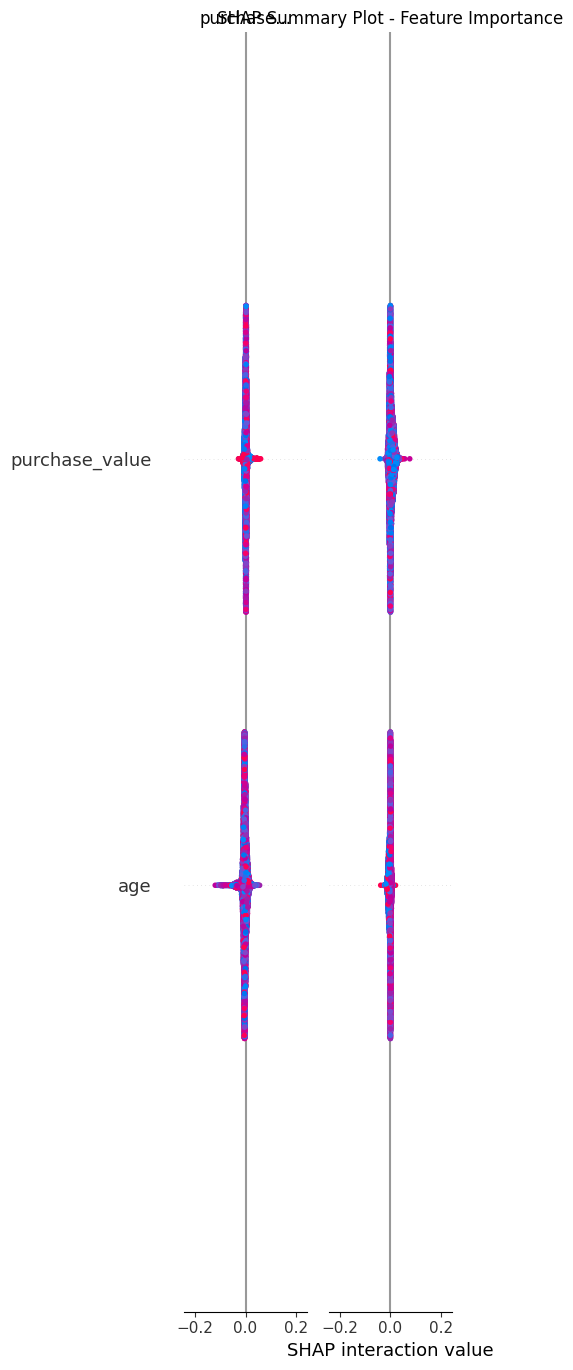

Error when computing importance: Per-column arrays must each be 1-dimensional
Manual arr ndim, shape: 3 (15111, 16, 2)
Reduce mean over sample axis -> (16, 2)
Reduce mean over sample+class axes -> (16,)
Reduce mean over sample+feature axes -> (2,)


In [13]:
import importlib
import src.explain as explain_mod
importlib.reload(explain_mod)

# Run SHAP explainability on a small sample
feature_names = X_small.columns.tolist()
expl = SHAPExplainer(model, feature_names)
expl.create_explainer(X_small, explainer_type='tree')
expl.calculate_shap_values(X_small)

# Diagnostic prints to help debug shapes
sv = expl.shap_values
print('shap_values type:', type(sv))
if isinstance(sv, list):
    print('list elements shapes:', [np.array(s).shape for s in sv])
else:
    arr = np.array(sv)
    print('arr ndim, shape:', arr.ndim, arr.shape)

# Summary plot (renders inline)
expl.plot_summary(X_small)

# Show top feature importance table (wrapped in try/except with diagnostics)
try:
    importance_df = expl.get_feature_importance()
    display(importance_df.head(10))
except Exception as e:
    print('Error when computing importance:', e)
    # Attempt manual computation for diagnostics
    try:
        arr = np.array(sv)
        print('Manual arr ndim, shape:', arr.ndim, arr.shape)
        if arr.ndim == 3:
            # try common reductions
            print('Reduce mean over sample axis ->', np.abs(arr).mean(axis=0).shape)
            print('Reduce mean over sample+class axes ->', np.abs(arr).mean(axis=(0,2)).shape)
            print('Reduce mean over sample+feature axes ->', np.abs(arr).mean(axis=(0,1)).shape)
    except Exception as e2:
        print('Manual diagnostic failed:', e2)